# Notebook de vérification du dataset — Healthy Illusion

Ce notebook vérifie le dataset généré par `src/data_collection.py`.

Objectifs :
- charger `data/dataset.csv` ;
- vérifier les dimensions ;
- vérifier les valeurs manquantes ;
- vérifier la cible `bad_nutrition` ;
- vérifier le ratio de la classe minoritaire entre 5% et 25% ;
- vérifier `image_saine` et `healthy_illusion` ;
- visualiser les distributions principales.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Chargement du dataset

In [2]:
DATASET_PATH = Path("../data/dataset.csv")

if not DATASET_PATH.exists():
    DATASET_PATH = Path("data/dataset.csv")

df = pd.read_csv(DATASET_PATH)

print("Dataset chargé depuis :", DATASET_PATH)
print("Dimensions :", df.shape)
df.head()

Dataset chargé depuis : ..\data\dataset.csv
Dimensions : (15114, 18)


,code,product_name,brands,main_category,country,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,proteins_100g,energy_kcal_100g,additives_count,has_labels,image_saine,nutriscore_grade,bad_nutrition,healthy_illusion
0,8001420011593,Basmati integrale,Gallo,plant-based-foods-and-beverages,italy,0.8,2.7,0.8,0.00,2.8,8.8,353.0,0,0,1,b,0,0
1,3329770075405,Yop Parfum vanille,Yoplait,beverages-and-beverages-preparations,france,10.4,0.8,0.5,0.12,1.9,3.0,66.0,0,1,1,d,1,1
2,6130837000509,Couscous,NaN,plant-based-foods-and-beverages,france,3.0,2.0,0.3,0.01,1.9,12.0,354.0,0,0,1,a,0,0
3,3250390011958,YAOURT AU LAIT ENTIER POT VERRE 4X125G - nature,Pâturages,dairies,france,4.0,3.4,2.4,0.10,0.0,3.7,63.8,0,1,1,b,0,0
4,3368954600231,Ravioles du Dauphiné,"U Saveurs,U de nos Régions,U",plant-based-foods-and-beverages,france,2.2,11.0,7.1,1.60,2.4,14.0,282.0,0,1,1,d,1,1


## 3. Types et valeurs manquantes

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                15114 non-null  object 
 1   product_name        14840 non-null  str    
 2   brands              14710 non-null  str    
 3   main_category       15114 non-null  str    
 4   country             15114 non-null  str    
 5   sugars_100g         15114 non-null  float64
 6   fat_100g            15114 non-null  float64
 7   saturated_fat_100g  15114 non-null  float64
 8   salt_100g           15114 non-null  float64
 9   fiber_100g          15114 non-null  float64
 10  proteins_100g       15114 non-null  float64
 11  energy_kcal_100g    15114 non-null  float64
 12  additives_count     15114 non-null  int64  
 13  has_labels          15114 non-null  int64  
 14  image_saine         15114 non-null  int64  
 15  nutriscore_grade    15114 non-null  str    
 16  bad_nutrition  

In [4]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

brands                404
product_name          274
code                    0
main_category           0
country                 0
sugars_100g             0
fat_100g                0
saturated_fat_100g      0
salt_100g               0
fiber_100g              0
proteins_100g           0
energy_kcal_100g        0
additives_count         0
has_labels              0
image_saine             0
nutriscore_grade        0
bad_nutrition           0
healthy_illusion        0
dtype: int64

## 4. Colonnes du dataset

In [5]:
print("Nombre de colonnes :", len(df.columns))
for col in df.columns:
    print("-", col)

Nombre de colonnes : 18
- code
- product_name
- brands
- main_category
- country
- sugars_100g
- fat_100g
- saturated_fat_100g
- salt_100g
- fiber_100g
- proteins_100g
- energy_kcal_100g
- additives_count
- has_labels
- image_saine
- nutriscore_grade
- bad_nutrition
- healthy_illusion


## 5. Vérification des contraintes

Contraintes :
- au moins 10 000 lignes ;
- au moins 8 features ;
- classe minoritaire entre 5% et 25% ;
- présence d’une variable cible supervisée.


In [6]:
target_col = "bad_nutrition"

feature_cols = [
    "sugars_100g",
    "fat_100g",
    "saturated_fat_100g",
    "salt_100g",
    "fiber_100g",
    "proteins_100g",
    "energy_kcal_100g",
    "additives_count",
    "main_category",
    "country",
    "has_labels",
    "image_saine",
]

n_rows = len(df)
n_features = len(feature_cols)
target_exists = target_col in df.columns

class_distribution = df[target_col].value_counts()
class_distribution_pct = df[target_col].value_counts(normalize=True) * 100
minority_ratio = class_distribution_pct.min()

checks = {
    "Lignes >= 10 000": n_rows >= 10_000,
    "Features >= 8": n_features >= 8,
    "Cible bad_nutrition présente": target_exists,
    "Classe minoritaire entre 5% et 25%": 5 <= minority_ratio <= 25,
}

print("Nombre de lignes :", n_rows)
print("Nombre de features ML :", n_features)
print("\nDistribution de la cible :")
print(class_distribution)
print("\nDistribution en pourcentage :")
print(class_distribution_pct.round(2))
print("\nRatio classe minoritaire :", round(minority_ratio, 2), "%")
print("\nVérifications :")
for key, value in checks.items():
    print(f"{key} : {'OK' if value else 'NON'}")

Nombre de lignes : 15114
Nombre de features ML : 12

Distribution de la cible :
bad_nutrition
0    12467
1     2647
Name: count, dtype: int64

Distribution en pourcentage :
bad_nutrition
0    82.49
1    17.51
Name: proportion, dtype: float64

Ratio classe minoritaire : 17.51 %

Vérifications :
Lignes >= 10 000 : OK
Features >= 8 : OK
Cible bad_nutrition présente : OK
Classe minoritaire entre 5% et 25% : OK


## 6. Distribution de la variable cible `bad_nutrition`

- `bad_nutrition = 0` : Nutri-Score A, B ou C ;
- `bad_nutrition = 1` : Nutri-Score D ou E.


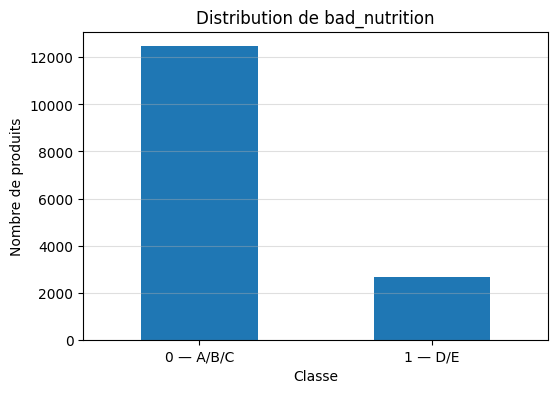

In [7]:
plt.figure(figsize=(6, 4))
class_distribution.sort_index().plot(kind="bar")
plt.title("Distribution de bad_nutrition")
plt.xlabel("Classe")
plt.ylabel("Nombre de produits")
plt.xticks(ticks=[0, 1], labels=["0 — A/B/C", "1 — D/E"], rotation=0)
plt.grid(axis="y", alpha=0.4)
plt.savefig("../figures/distribution_bad_nutrition.png", bbox_inches="tight", dpi=300)
plt.show()

## 7. Distribution de `image_saine` et `healthy_illusion`

- `image_saine` indique si le produit appartient à une catégorie ou possède un label associé à une image saine.
- `healthy_illusion = 1` si `image_saine = 1` et `bad_nutrition = 1`.


In [8]:
for col in ["image_saine", "healthy_illusion"]:
    print(f"Distribution de {col} :")
    print(df[col].value_counts())
    print()
    print((df[col].value_counts(normalize=True) * 100).round(2))
    print("-" * 40)

Distribution de image_saine :
image_saine
1    12624
0     2490
Name: count, dtype: int64

image_saine
1    83.53
0    16.47
Name: proportion, dtype: float64
----------------------------------------
Distribution de healthy_illusion :
healthy_illusion
0    13025
1     2089
Name: count, dtype: int64

healthy_illusion
0    86.18
1    13.82
Name: proportion, dtype: float64
----------------------------------------


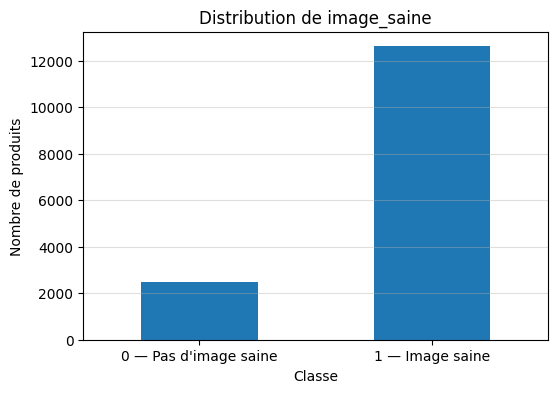

In [9]:
plt.figure(figsize=(6, 4))
df["image_saine"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de image_saine")
plt.xlabel("Classe")
plt.ylabel("Nombre de produits")
plt.xticks(ticks=[0, 1], labels=["0 — Pas d'image saine", "1 — Image saine"], rotation=0)
plt.grid(axis="y", alpha=0.4)
plt.savefig("../figures/distribution_image_saine.png", bbox_inches="tight", dpi=300)
plt.show()

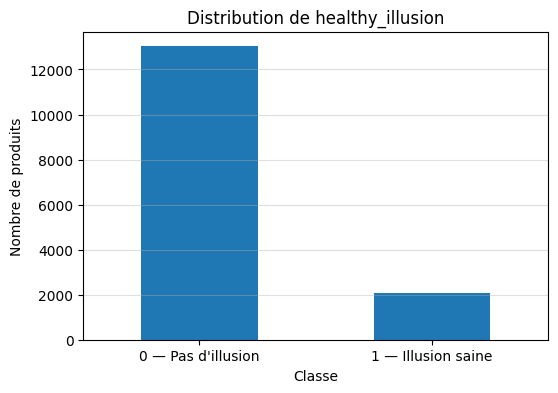

In [10]:
plt.figure(figsize=(6, 4))
df["healthy_illusion"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de healthy_illusion")
plt.xlabel("Classe")
plt.ylabel("Nombre de produits")
plt.xticks(ticks=[0, 1], labels=["0 — Pas d'illusion", "1 — Illusion saine"], rotation=0)
plt.grid(axis="y", alpha=0.4)
plt.savefig("../figures/distribution_healthy_illusion.png", bbox_inches="tight", dpi=300)
plt.show()

## 8. Aperçu des catégories principales

In [11]:
df["main_category"].value_counts().head(15)

main_category
plant-based-foods-and-beverages         7964
dairies                                 2723
beverages-and-beverages-preparations    2156
condiments                               836
seafood                                  820
snacks                                   302
beverages                                287
canned-foods                              14
sports-nutrition                           8
energy-gel                                 1
fermented-foods                            1
sports                                     1
frozen-foods                               1
Name: count, dtype: int64

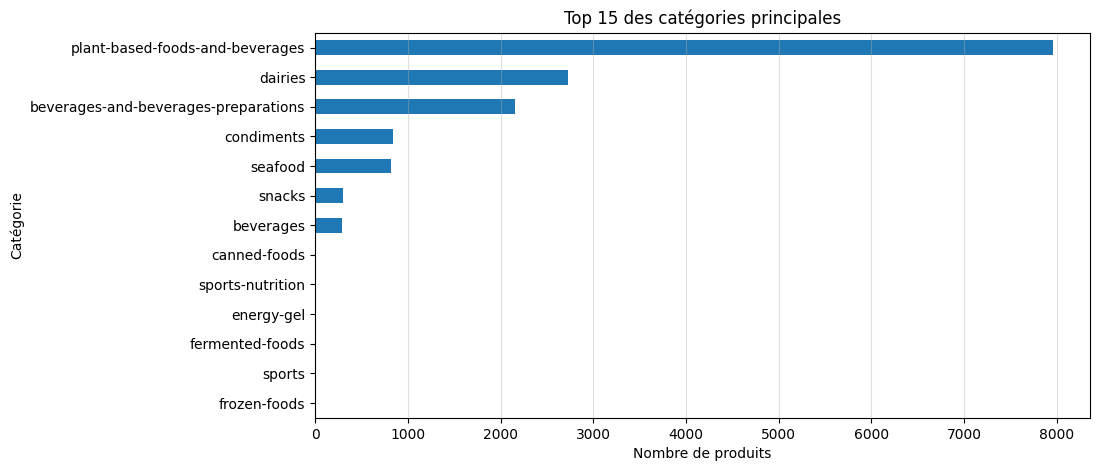

In [12]:
plt.figure(figsize=(10, 5))
df["main_category"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 des catégories principales")
plt.xlabel("Nombre de produits")
plt.ylabel("Catégorie")
plt.grid(axis="x", alpha=0.4)
plt.show()

## 9. Analyse rapide des variables numériques

In [13]:
numeric_cols = [
    "sugars_100g",
    "fat_100g",
    "saturated_fat_100g",
    "salt_100g",
    "fiber_100g",
    "proteins_100g",
    "energy_kcal_100g",
    "additives_count",
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sugars_100g,15114.0,6.272528e+00,8.240303e+00,0.0,0.599449,3.5,9.556266,1.128571e+02
fat_100g,15114.0,4.845430e+00,9.015331e+00,0.0,0.500000,1.8,4.500000,1.000000e+02
saturated_fat_100g,15114.0,1.648855e+00,3.742626e+00,0.0,0.100000,0.4,1.700000,5.200000e+01
salt_100g,15114.0,6.102239e-01,1.713293e+01,0.0,0.010000,0.1,0.542375,1.820000e+03
fiber_100g,15114.0,4.043431e+08,4.970954e+10,0.0,0.800000,1.9,3.800000,6.111242e+12
proteins_100g,15114.0,6.780757e+00,6.628645e+00,0.0,1.600000,5.3,9.400000,8.500000e+01
energy_kcal_100g,15114.0,1.883505e+02,2.183904e+02,0.0,57.000000,110.0,350.000000,1.700000e+04
additives_count,15114.0,5.889242e-01,1.275179e+00,0.0,0.000000,0.0,1.000000,1.400000e+01
